Title: Simple_Energy_Model.ipynb

Purpose: Calculate a simple energy model

Author: Onno Nennecke on 22 January 2025 Modified: 18.02.2025

Input data: 

    - Gridded data of hub height (for on- and offshore installations) 
    - Gridded data of installed capacities (on- and offshore + solar)
    - Climate data:
        - surface Wind speed

Output data:

    - This file lies here: 

Import packages

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

Load data

In [2]:
grid_offsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')
grid_onsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')

In [3]:
# Installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_power.nc')
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_power.nc')
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_power.nc')

In [4]:
# mask1 = xr.ufuncs.isnan(grid_offshore)
# mask2 = xr.ufuncs.isnan(grid_onshore)
# mask3 = xr.ufuncs.isnan(grid_solar)

# Combine the masks to find cells that are NaN in all three DataArrays
# mask = ~(mask1['wind_off_cap'] & mask2['wind_on_cap'] & mask3['solar_cap'])
# mask

In [5]:
# Load Wind data
scenario = 'CESM2' 
run = 'r1i1p1f1' # r10i1p1f1  r11i1p1f1  r1i1p1f1  r2i1p1f1  r3i1p1f1  r4i1p1f1  r5i1p1f1  r6i1p1f1  r7i1p1f1  r8i1p1f1  r9i1p1f1
variable = 'sfcWind' # Surface Wind Speed
nc = xr.open_mfdataset(f'/climca/data/CMIP6/CMIP/NCAR/{scenario}/historical/{run}/day/{variable}/gn/v20190308/{variable}_day_{scenario}_historical_{run}_gn_*')

/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), n

In [6]:
nc

<xarray.Dataset> Size: 14GB
Dimensions:    (time: 60226, lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * time       (time) object 482kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
Dimensions without coordinates: nbnd
Data variables:
    sfcWind    (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    time_bnds  (time, nbnd) object 964kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (time, lat, nbnd) float32 93MB dask.array<chunksize=(3650, 192, 2), meta=np.ndarray>
    lon_bnds   (time, lon, nbnd) float32 139MB dask.array<chunksize=(3650, 288, 2), meta=np.ndarray>
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-16T22:00:26Z
    ...                     ...
    sub_experiment:         none
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...

In [7]:
# select variable
sfcWind = nc['sfcWind'] 
sfcWind
# filter winter
sfcWind = sfcWind[np.isin(sfcWind.time.dt.month, [10,11,12,1,2,3]),:,:]
sfcWind
# select region
sfcWind = sfcWind.sel(dict(lat=slice(45,60), lon=slice(5,15))) # At the moment roughly germany
sfcWind

<xarray.DataArray 'sfcWind' (time: 30031, lat: 16, lon: 9)> Size: 17MB
dask.array<getitem, shape=(30031, 16, 9), dtype=float32, chunksize=(1, 16, 9), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
Attributes: (12/19)
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        near-surface (usually, 10 meters) wind speed.
    description:    near-surface (usually, 10 meters) wind speed.
    frequency:      day
    id:             sfcWind
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Daily-Mean Near-Surface Wind Speed
    type:           real
    units:          m s-1
    variable_id:    sfcWind

In [8]:
# Calculate power from wind speed

alpha_on = 1/7 # Roughness parameter onshore
alpha_off = 0.11 # Roughness parameter offshore
ref_height = 10 # Height of wind data
v_cutin = 3.5 # Minimum wind speed to start producing power
v_cutout = 25 # Maximum wind speed to produce power
v_rated = 13 # Wind speed at which the turbine produces maximum power
# hub_height_on = 80 # Approximation: Onshore 80 m --> Bad Approximation
hub_height_on = grid_onsh_hub_height['wind_on_hub_height']
# hub_height_off = 120 # Approximation: Offshore 120 m --> Bad Approximation
hub_height_off = grid_offsh_hub_height['wind_off_hub_height']

In [9]:
# Calculate wind speed at hub height

def _wind_scale(wind_at_ref_height, hub_height, surface_roughness, reference_height):
    """
    Scales wind at reference height to wind at hub_height with a power law profile.

    parameters
    ----------
    wind_at_ref_height (xarray.DataArray): wind speed [m s**-1]
    hub_height (float): the hub height of the wind turbines [m]
    surface_roughness (float): the roughness parameter of the surface [-]
    reference_height (float): reference height of wind speed [m].

    returns
    -------
    wind_at_hub_height (xarray.DataArray): estimated wind speed at height of the hub [m s**-1]
    """
    wind_at_hub_height = (
        wind_at_ref_height * (hub_height / reference_height) ** surface_roughness
    )

    return wind_at_hub_height

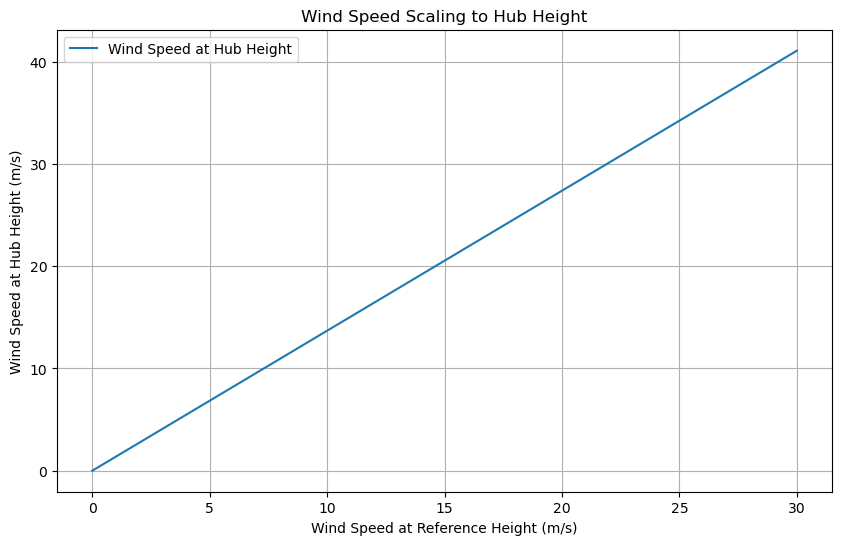

In [10]:
# Plot Wind profile power law
wind_speeds = np.linspace(0, 30, 100)

# Define hub height, surface roughness, and reference height
hub_height_plt = 90

# Calculate wind speeds at hub height
wind_speeds_at_hub_height = _wind_scale(wind_speeds, hub_height_plt, alpha_on, ref_height)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(wind_speeds, wind_speeds_at_hub_height, label='Wind Speed at Hub Height')
plt.xlabel('Wind Speed at Reference Height (m/s)')
plt.ylabel('Wind Speed at Hub Height (m/s)')
plt.title('Wind Speed Scaling to Hub Height')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
sfcWind_at_height_offshore = _wind_scale(sfcWind, hub_height_off, alpha_off, ref_height)

sfcWind_at_height_onshore = _wind_scale(sfcWind, hub_height_on, alpha_on, ref_height)

In [12]:
def _wind_power_curve(wind_at_hub_height, v_cutin, v_rated, v_cutout):
    """
    Computes wind energy potential with a powercurve based on wind speed at hub height.

    parameters
    ----------
    wind_at_hub_height (xarray.DataArray): wind speed at hub height [m s**-1]
    v_cutin (float): cut-in wind speed [m s**-1]
    v_rated (float): rated wind speed [m s**-1]
    v_cutout (float): cut-out wind speec [m s**-1]


    returns
    -------
    wind_energy_potential (xarray.DataArray): potential of wind energy at location and time [-]
    """
    wind_speed = wind_at_hub_height
    wind_energy_pot = (wind_at_hub_height**3 - v_cutin**3) / (
        v_rated**3 - v_cutin**3
    )
    wind_energy_pot = xr.where(wind_speed < v_cutin, 0, wind_energy_pot)
    wind_energy_pot = xr.where(wind_speed >= v_rated, 1, wind_energy_pot)
    wind_energy_pot = xr.where(wind_speed >= v_cutout, 0, wind_energy_pot)

    return wind_energy_pot

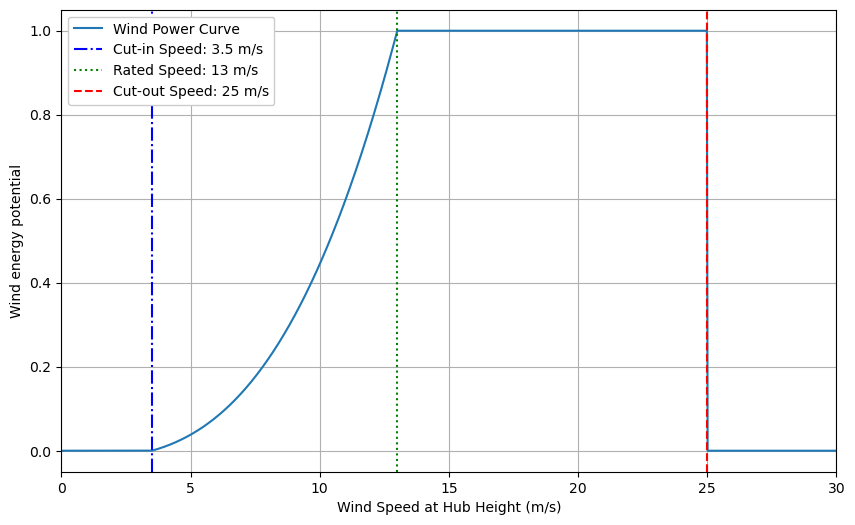

In [26]:
# Plot Wind profile power law
wind_speeds_plot = np.linspace(0, 30, 1000)

# Calculate wind speeds at hub height
wind_energy_prod_plot = _wind_power_curve(wind_speeds_plot, v_cutin, v_rated, v_cutout)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(wind_speeds_plot, wind_energy_prod_plot, label='Wind Power Curve')
plt.axvline(x=v_cutin, color='b', linestyle='-.', label=f'Cut-in Speed: {v_cutin} m/s')
plt.xlim(0, 30)
plt.axvline(x=v_rated, color='g', linestyle=':', label=f'Rated Speed: {v_rated} m/s')
plt.axvline(x=v_cutout, color='r', linestyle='--', label=f'Cut-out Speed: {v_cutout} m/s')
plt.xlabel('Wind Speed at Hub Height (m/s)')
plt.ylabel('Wind energy potential')
# plt.title('Wind power curve')
plt.legend(facecolor='white', framealpha=1)
plt.grid(True)

# Save plot
plt.savefig('Figures/Wind_power_curve.png', dpi=300, bbox_inches='tight')

plt.show()

In [27]:
wind_power_offshore = xr.apply_ufunc(_wind_power_curve, sfcWind_at_height_offshore, v_cutin, v_rated, v_cutout, dask='parallelized') # , output_dtypes=[float]
wind_power_offshore

wind_power_onshore = xr.apply_ufunc(_wind_power_curve, sfcWind_at_height_onshore, v_cutin, v_rated, v_cutout, dask='parallelized') # , output_dtypes=[float]
wind_power_onshore

<xarray.DataArray (time: 30031, lat: 16, lon: 9)> Size: 35MB
dask.array<transpose, shape=(30031, 16, 9), dtype=float64, chunksize=(1, 16, 9), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
    crs      int64 8B ...

In [28]:
# wind_power_offshore = wind_power_offshore.where(mask, np.nan)
# wind_power_onshore = wind_power_onshore.where(mask, np.nan)

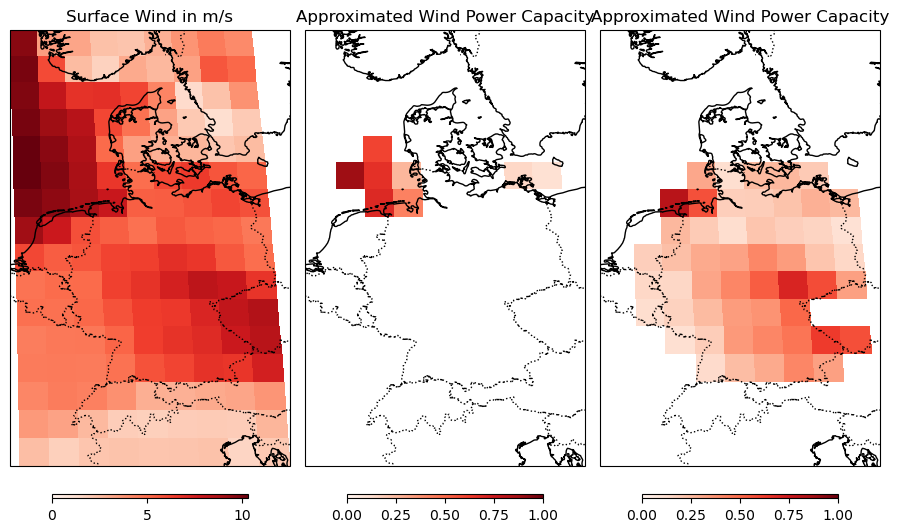

In [29]:
lon_edges = sfcWind.lon.values - (sfcWind.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = sfcWind.lat.values - (sfcWind.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 1# 10000 # 24507

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = sfcWind.isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Surface Wind in m/s')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = wind_power_offshore.isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Wind Power Capacity')

# Third subplot
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx3 = wind_power_onshore.isel(time=timestep)
im3 = ax3.pcolormesh(lon_edges, lat_edges, xxx3, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar3 = fig.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax3.set_title('Approximated Wind Power Capacity')


plt.tight_layout()
plt.show()

In [17]:
# Now multiply this for the power output
wind_energy_prod_off = wind_power_offshore * grid_offshore
wind_energy_prod_off

wind_energy_prod_on = wind_power_onshore * grid_onshore
wind_energy_prod_on

# And add both results for total wind energy production
wind_energy_prod = xr.Dataset({
    "wind_energy": wind_energy_prod_on["wind_on_cap"].fillna(0) + wind_energy_prod_off["wind_off_cap"].fillna(0)
})

# Restore NaNs where both were originally NaN
wind_energy_prod = wind_energy_prod.where(
    wind_energy_prod_on["wind_on_cap"].notnull() | wind_energy_prod_off["wind_off_cap"].notnull()
)


In [20]:
wind_energy_prod_on['wind_on_cap'].isel(time = 1).values * 24

array([[           nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
                   nan],
       [           nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
                   nan],
       [           nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
                   nan],
       [           nan,            nan,            nan, 1.10647522e+06,
        5.49302376e+05, 1.33440695e+06, 5.44647816e+05, 4.18360802e+04,
                   nan],
       [           nan,            nan, 9.54968955e+05, 1.49839785e+06,
        5.17727384e+06, 9.51141806e+06, 3.73860996e+06, 1.98731294e+05,
        8.50338409e+03],
       [           nan, 2.05807762e+05, 9.96135395e+06, 1.06087703e+07,
        8.49201876e+06, 6.43289467e+06, 7.46044800e+06,            nan,
           

In [28]:
# Aggregate wind energy production by time (sum)
wind_energy_prod_sum = wind_energy_prod.sum(dim=['lat', 'lon'])
wind_energy_prod_sum

<xarray.Dataset> Size: 481kB
Dimensions:      (time: 30031)
Coordinates:
    crs          int64 8B 4326
  * time         (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
Data variables:
    wind_energy  (time) float64 240kB dask.array<chunksize=(1,), meta=np.ndarray>

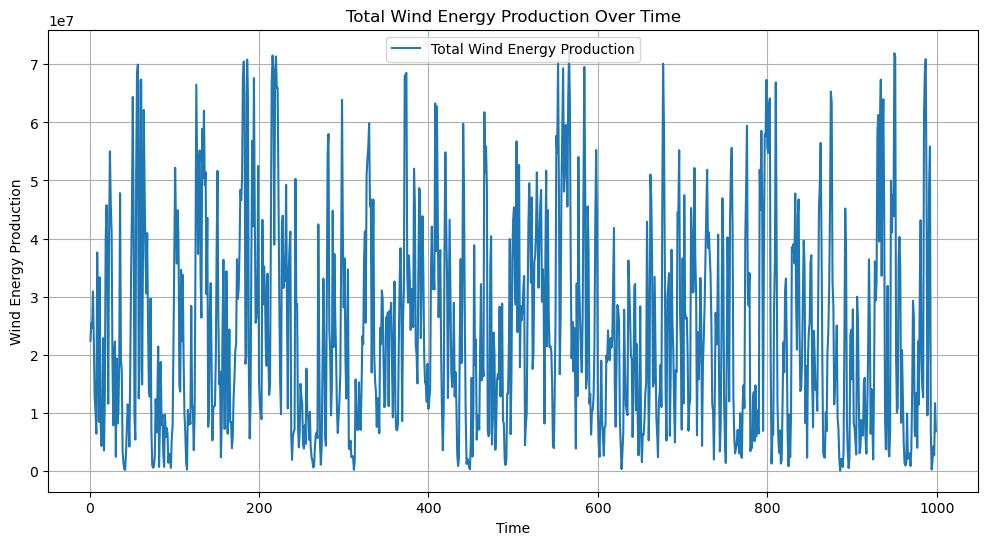

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(np.arange(1,1000), wind_energy_prod_sum['wind_energy'][1:1000].values, label='Total Wind Energy Production')
plt.xlabel('Time')
plt.ylabel('Wind Energy Production')
plt.title('Total Wind Energy Production Over Time')
plt.legend()
plt.grid(True)
plt.show()


## Solar

In [25]:
# Solar capacity:
variable = 'rsds' # Surface Downwelling Shortwave Radiation
nc = xr.open_mfdataset(f'/climca/data/CMIP6/CMIP/NCAR/{scenario}/historical/{run}/day/{variable}/gn/v20190308/{variable}_day_{scenario}_historical_{run}_gn_*')
# select variable
rsds = nc['rsds'] 
rsds
# filter winter
rsds = rsds[np.isin(rsds.time.dt.month, [10,11,12,1,2,3]),:,:]
rsds
# select region
rsds = rsds.sel(dict(lat=slice(45,60), lon=slice(5,15))) # At the moment roughly germany
rsds

/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e

<xarray.DataArray 'rsds' (time: 30031, lat: 16, lon: 9)> Size: 17MB
dask.array<getitem, shape=(30031, 16, 9), dtype=float32, chunksize=(1, 16, 9), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
Attributes: (12/20)
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        Surface solar irradiance for UV calculations.
    description:    Surface solar irradiance for UV calculations.
    frequency:      day
    id:             rsds
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Surface Downwelling Shortwave Radiation
    type:           real
    units:          W m-2
    variable_id:    rsds

In [26]:
# Temperature:
variable = 'tas' # 
nc = xr.open_mfdataset(f'/climca/data/CMIP6/CMIP/NCAR/{scenario}/historical/{run}/day/{variable}/gn/v20190308/{variable}_day_{scenario}_historical_{run}_gn_*')
# select variable
tas = nc['tas'] 
tas
# filter winter
tas = tas[np.isin(tas.time.dt.month, [10,11,12,1,2,3]),:,:]
tas
# select region
tas = tas.sel(dict(lat=slice(45,60), lon=slice(5,15))) # At the moment roughly germany
tas

/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)

<xarray.DataArray 'tas' (time: 30031, lat: 16, lon: 9)> Size: 17MB
dask.array<getitem, shape=(30031, 16, 9), dtype=float32, chunksize=(1, 16, 9), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
Attributes: (12/19)
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        near-surface (usually, 2 meter) air temperature
    description:    near-surface (usually, 2 meter) air temperature
    frequency:      day
    id:             tas
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Near-Surface Air Temperature
    type:           real
    units:          K
    variable_id:    tas

In [27]:
shift_doy = 186  # if HadGEM : 180
PI = np.pi

def _day_length(data, shift_doy=shift_doy):
    """
    Computes the number of daylight hours at locations and times for a given dataset

    parameters
    ----------
    dataset (xarray.DataArray(coor)): a dataset with coordinates time and lat and lon

    returns
    -------
    daylight_hours (xarray.DataArray): hours of daylight for date and location [h]
    """
    day_of_year = data.time.dt.dayofyear

    lat = data.lat

    p = 0.0
    P = np.arcsin( 0.39795 * np.cos(0.2163108 + 2 * np.arctan(0.9671396 * np.tan(0.00860 * (day_of_year - shift_doy))) ) )

    arg = (np.sin(p * PI / 180) + np.sin(lat * PI / 180) * np.sin(P)) / ( np.cos(lat * PI / 180) * np.cos(P) )

    arg = xr.where(arg < -1, -1, arg)
    arg = xr.where(arg > 1, 1, arg)

    daylight_hours = 24 - 24 / PI * np.arccos(arg)

    return daylight_hours


In [28]:
day_of_year = tas.time.dt.dayofyear
# day_of_year.values[0:200]

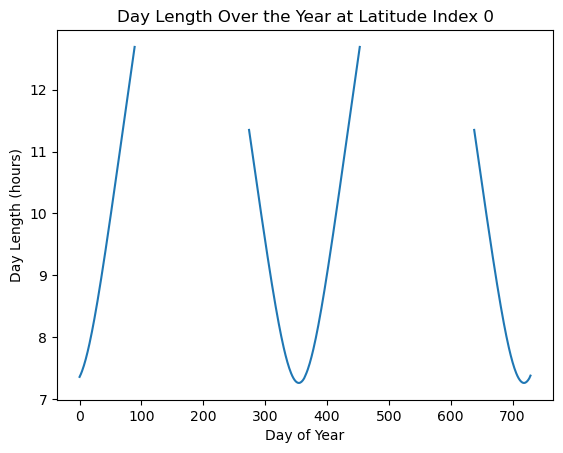

In [29]:
# Select a specific latitude (e.g., the first latitude)
latitude_index = 8
x = np.concatenate([np.arange(0, 90), np.full(184, np.nan), np.arange(274, 365+89), np.full(184, np.nan), np.arange(638, 730)])
plt.plot(x, _day_length(tas).isel(time=slice(0, 365*2), lat=latitude_index).values)
plt.xlabel('Day of Year')
plt.ylabel('Day Length (hours)')
plt.title('Day Length Over the Year at Latitude Index 0')
plt.show()

In [30]:
# Calculate solar capacity
gamma = -0.005 # 
Tref = 25 # 
c_1 = 4.3 #
c_2 = 0.943 #
c_3 = 0.028 #
c_4 = -1.528 #
G = rsds
G_stc = 1000  # standard test conditions [W m-2]
KELVIN = 273.15

In [31]:
def _solar_cell_temp(radiation, temp_at_sfc, temp_at_sfc_max, surface_wind):
    """
    Computes solar cell temperature

    parameters
    ----------
    radiation (xarray.DataArray): incoming mean daily solar radiation [W m**-2]
    temp_at_sfc (xarray.DataArray): mean daily temperature at surface [degC]
    temp_at_sfc_max (xarray.DataArray): maximum daily temperature [degC]
    surface_wind (xarray.DataArray): mean daily wind at 10 m [m s**-1]

    returns
    -------
    cell_temperature (xarray.DataArray): temperature of the cell [degC]
    """
    
    c_1 = 4.3       #
    c_2 = 0.943     #
    c_3 = 0.028     #
    c_4 = -1.528    #
    
    daily_temp_2m = (temp_at_sfc + temp_at_sfc_max) / 2

    cell_temperature = (
        c_1 + c_2 * daily_temp_2m + c_3 * radiation + c_4 * surface_wind
    )

    return cell_temperature

In [32]:
def _solar_performance_ratio(cell_temperature, gamma = -0.005, ref_temp = 25):
    """
    Computes performance ratio of the

    parameters
    ----------
    cell_temperature (xarray.DataArray): temperature of the cell [degC]
    gamma (float): constant for performance ratio [-]
    ref_temp (float): reference temperature for performance ratio calculation [degC]


    returns
    -------
    performance_ratio (xarray.DataArray): performance ratio of solar cell [-]
    """
    gamma = -0.005  # 
    ref_temp = 25   #
    
    performance_ratio = 1 + gamma * (cell_temperature - ref_temp)

    return performance_ratio

In [33]:
def _solar_potential(performance_ratio, radiation, standard_radiation = 1000):
    """
    Computes theoretical solar power potential

    parameters
    ----------
    performance_ratio (xarray.DataArray): performance ratio of solar cell [-]
    radiation (xarray.DataArray): incoming mean daily solar radiation [W m**-2]
    standard_radiation (int): the incoming radiation under standard test conditions [W m**-1]

    returns
    -------
    solar_energy_potential (xarray.DataArray): the daily potential for solar energy production [-]

    """
    standard_radiation = 1000
    
    solar_energy_potential = performance_ratio * radiation / standard_radiation

    return solar_energy_potential

In [34]:
def compute_solar_energy_potential(
    radiation,
    temp_at_sfc,
    temp_at_sfc_max,
    surface_wind#,
    # energy_type="solar",
    # unit="[0-1]",
):
    """
    Computes solar energy production based on incoming radiation and performance ratio

    parameters
    ----------
    radiation (xarray.DataArray): incoming mean daily solar radiation [W m**-2]
    temp_at_sfc (xarray.DataArray): mean daily temperature at surface [Kelvin]
    temp_at_sfc_max (xarray.DataArray): maximum daily temperature [Kelvin]
    surface_wind (xarray.DataArray): mean daily wind at 10 m [m s**-1]

    predefined parameters
    ----------
    constants (list of floats): list with 4 constants for cell temperature
        calculations [-]. Default is connstants_pv
    gamma (float): constant for performance ratio [-]. Defailt is GAMMA.
    ref_temp (float): reference temperature for performance ratio
        calculation [degC]. Default is TEMP_REF
    standard_radiation (int): the incoming radiation under standard test
        conditions [W m**-1]. Default is GSTC
    energy_type (string): the (new) short name of of the energy_type that
        will be updated. Default is -solar-
    unit (string): the units of the energy_type that should be updated.
        Default is 'TWh day **-1'

    returns
    -------
    solar_energy_potential (xarray.DataArray): potential of solar energy at
        location and time [no unit]

    """
    KELVIN = 273.15
    daylight_hours = _day_length(temp_at_sfc)

    radiation_day = radiation * 24 / daylight_hours
    radiation_day = xr.where(daylight_hours == 0, 0, radiation_day)

    temp_at_sfc = temp_at_sfc - KELVIN
    temp_at_sfc_max = temp_at_sfc_max - KELVIN
    cell_temperature = _solar_cell_temp(
        radiation_day, temp_at_sfc, temp_at_sfc_max, surface_wind
    )
    performance_ratio = _solar_performance_ratio(cell_temperature)
    solar_energy_pot = _solar_potential(
        performance_ratio, radiation_day
    )

    # solar_energy_pot = attributes.update_energy_attributes(
    #     solar_energy_pot, energy_type, unit, potential=True
    # )

    return solar_energy_pot

In [35]:

def compute_solar_energy_production(
    solar_energy_pot, spatial_distribution #, energy_type="solar", unit="MWh d**-1"
):
    """
    Computes solar energy production based on incoming radiation and performance ratio

    parameters
    ----------
    spatial_distribution (xarray.DataArray): spatial distribution of
        installed solar capacity [MW]

    predefined parameters
    ----------
    energy_type (string): the (new) short name of of the energy_type that
        will be updated. Default is 'solar'
    unit (string): the units of the energy_type that should be updated.
        Default is 'TWh day **-1'

    returns
    -------
    solar_energy_prod (xarray.DataArray): production of solar energy at
        location and time [TWh day **-1]
    eu_solar_energy_prod (xarray.DataArray): sum of solar energy production
        in europe [TWh day **-1]
    """
    # make sure there are no rounding differences in lats between spatial and climate data
    # spatial_distribution = spatial_distribution.reindex_like(
    #     solar_energy_pot, method="nearest", tolerance=1e-5
    # )

    daylight_hours = _day_length(solar_energy_pot)

    solar_energy_cf = solar_energy_pot * daylight_hours

    solar_energy_prod = solar_energy_cf * spatial_distribution
    # update attributes
    # solar_energy_prod = attributes.update_energy_attributes(
    #     solar_energy_prod, energy_type, unit
    # )

    return solar_energy_prod

In [36]:
sepot = compute_solar_energy_potential(rsds, tas, tas, sfcWind)
sepro = compute_solar_energy_production(sepot, grid_solar)

In [37]:
sepro['solar_cap']

<xarray.DataArray 'solar_cap' (time: 30031, lat: 16, lon: 9)> Size: 35MB
dask.array<mul, shape=(30031, 16, 9), dtype=float64, chunksize=(1, 16, 9), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
    crs      int64 8B ...
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00

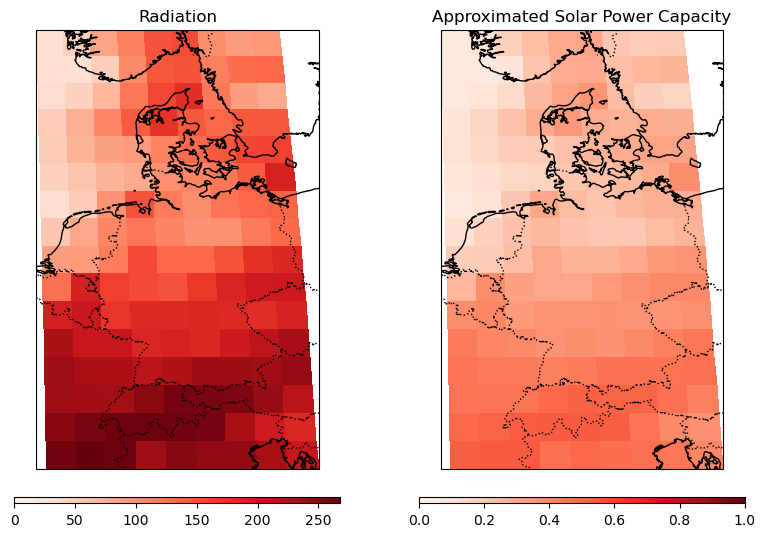

In [43]:
lon_edges = rsds.lon.values - (rsds.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = rsds.lat.values - (rsds.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 29937 # 10000 # 24507

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = rsds.isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Radiation')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = sepot.isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Solar Power Capacity')

plt.tight_layout()
plt.show()

In [40]:
sepro['solar_cap'].isel(time = 1).values

array([[           nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
                   nan],
       [           nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
                   nan],
       [           nan,            nan,            nan, 5.77182840e+04,
        2.09265834e+04, 6.80384564e+04, 2.36260325e+03, 6.87985776e+03,
                   nan],
       [           nan,            nan,            nan, 1.57849737e+06,
        1.70756941e+06, 1.30826574e+06, 8.25307126e+05, 5.26045139e+05,
                   nan],
       [           nan,            nan, 1.16495956e+06, 2.78421095e+06,
        2.68255479e+06, 1.71837699e+06, 1.43734304e+06, 9.23475648e+05,
        9.77180914e+03],
       [           nan, 3.81029908e+04, 3.04091980e+06, 3.08752429e+06,
        2.06774282e+06, 1.46664126e+06, 8.12746106e+05, 9.50073231e+03,
           

In [29]:
# Identification of low wind energy periods
event_duration = 3 # days
threshold = 0.01 # m/s

low_wind_energy = wind_power_reg_avg.where(wind_power_reg_avg < threshold, drop=False)

In [30]:
# wind_power_reg_avg
nan_count = np.isnan(low_wind_energy.values).sum()

nan_count

np.int64(29963)

In [31]:
low_wind_energy

<xarray.DataArray 'sfcWind' (time: 30031)> Size: 240kB
dask.array<where, shape=(30031,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00

In [32]:
# First Method: Constantly-BelowThreshold (CBT)
threshold =  0.01 # m/s

low_wind_energy = sfcWind_reg_avg.where(sfcWind_reg_avg < threshold, drop=False)
low_wind_energy

<xarray.DataArray 'sfcWind' (time: 30031)> Size: 240kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(30031,))
Coordinates:
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00

In [33]:
# aufpassen mit Feb -> Dez
sfcWind_reg_avg_roll = sfcWind_reg_avg.rolling(time=7, center=False).mean()

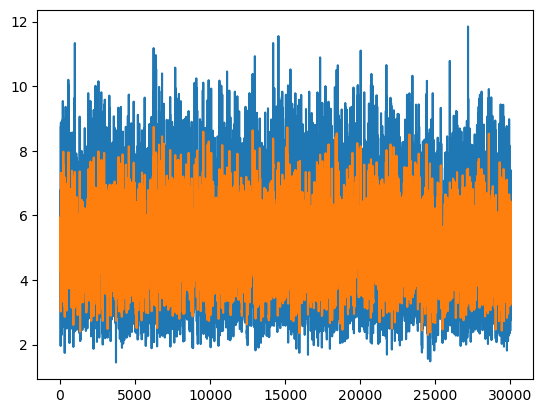

In [20]:
plt.plot(sfcWind_reg_avg)
plt.plot(sfcWind_reg_avg_roll)

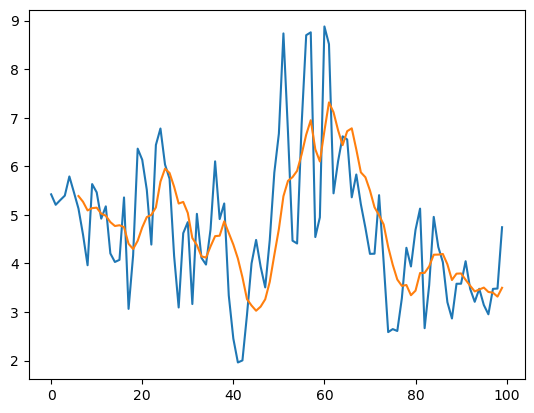

In [21]:
plt.plot(sfcWind_reg_avg[:100])
plt.plot(sfcWind_reg_avg_roll[:100])

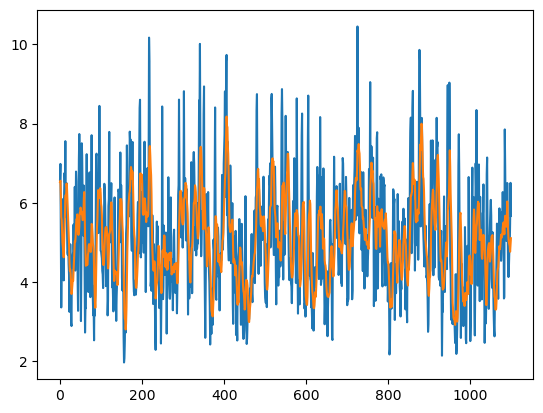

In [22]:
plt.plot(sfcWind_reg_avg[10400:11500])
plt.plot(sfcWind_reg_avg_roll[10400:11500])

In [23]:
# Find weeks with lowest average wind speed
lowest_indices = np.argsort(sfcWind_reg_avg_roll.values)[:10]
lowest_indices
# sfcWind_reg_avg_roll[lowest_indices]

array([24506, 24504, 24505, 15944, 24658,  1337, 24657, 15943, 24507,
       29420])

In [24]:
# !!! not yet possible as for other simulation run -- not comparable
# plot PSL and Z500 maps for 10 most extreme temperatures

variable = 'PSL' # Temperature at Reference Height
nc_psl = xr.open_mfdataset(f'/climca/data/CESM2_LE/{variable}/day_raw/b.e21.{scenario}.f09_g17.{run}.cam.h1.{variable}.*')

In [16]:
nc_psl

<xarray.Dataset> Size: 13GB
Dimensions:       (time: 60226, lat: 192, lev: 32, ilev: 33, nbnd: 2, lon: 288)
Coordinates:
  * lat           (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon           (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lev           (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 264B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time          (time) object 482kB 1850-01-01 00:00:00 ... 2015-01-01 00:0...
Dimensions without coordinates: nbnd
Data variables: (12/26)
    gw            (time, lat) float64 93MB dask.array<chunksize=(3650, 192), meta=np.ndarray>
    hyam          (time, lev) float64 15MB dask.array<chunksize=(3650, 32), meta=np.ndarray>
    hybm          (time, lev) float64 15MB dask.array<chunksize=(3650, 32), meta=np.ndarray>
    P0            (time) float64 482kB 1e+05 1e+05 1e+05 ... 1e+05 1e+05 1e+05
    hyai          (time, ilev) float64 16MB dask.array<chunksize=(3650, 33), meta=np.ndarray>
    hybi          (time, ilev) float64 16MB dask.array<chunksize=(3650, 33), meta=np.ndarray>
    ...            ...
    n2ovmr        (time) float64 482kB dask.array<chunksize=(512,), meta=np.ndarray>
    f11vmr        (time) float64 482kB dask.array<chunksize=(512,), meta=np.ndarray>
    f12vmr        (time) float64 482kB dask.array<chunksize=(512,), meta=np.ndarray>
    sol_tsi       (time) float64 482kB dask.array<chunksize=(512,), meta=np.ndarray>
    nsteph        (time) float64 482kB dask.array<chunksize=(1024,), meta=np.ndarray>
    PSL           (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e21.BHISTcmip6.f09_g17.LE2-1001.001
    logname:           sunseon
    host:              mom1
    initial_file:      b.e21.B1850.f09_g17.CMIP6-piControl.001.cam.i.1001-01-...
    topography_file:   /mnt/lustre/share/CESM/cesm_input/atm/cam/topo/fv_0.9x...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1

In [25]:
nc_psl

# select variable
psl = nc_psl['PSL'] # Pressure at Sea Level

# filter winter
psl = psl[np.isin(psl.time.dt.month, [12,1,2]),:,:]
# psl

# select region
psl_1 = psl.sel(dict(lat=slice(10,90), lon= slice(280,360)))
psl_2 = psl.sel(dict(lat=slice(10,90), lon= slice(0,40)))

psl = xr.concat([psl_1, psl_2], dim='lon')


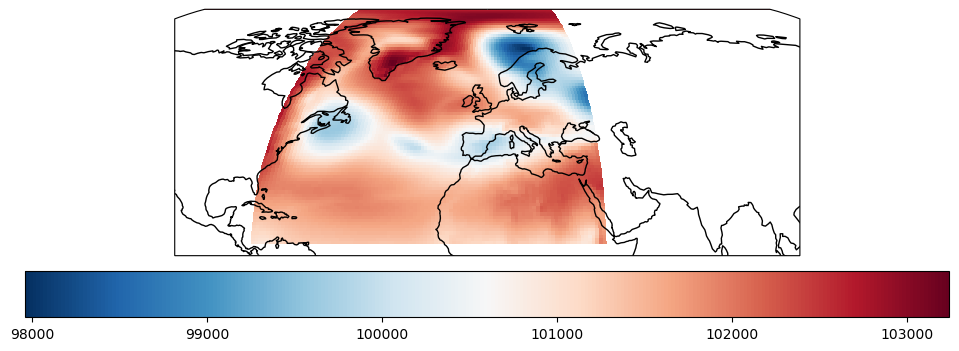

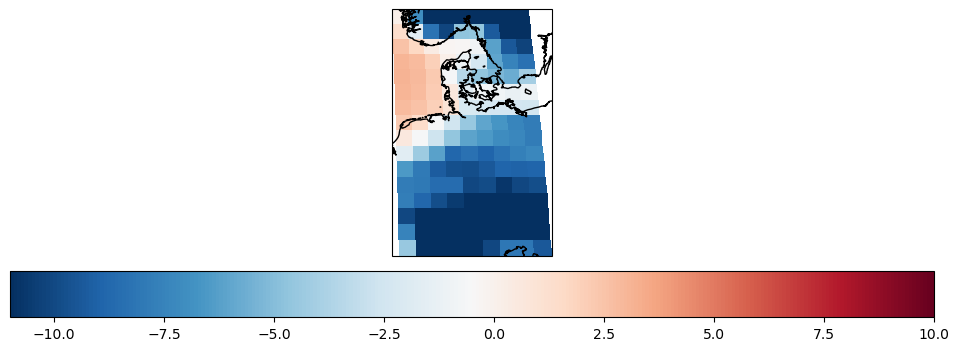

In [26]:
timestep = 11450

fig,ax = plt.subplots(nrows=1, figsize=(12, 4), subplot_kw={'projection': ccrs.crs.Robinson()})
ax.coastlines()
xxx = psl.isel(time=timestep)
im = ax.pcolormesh(xxx.lon, xxx.lat, xxx, transform=ccrs.crs.PlateCarree(), cmap='RdBu_r')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05)

fig,ax = plt.subplots(nrows=1, figsize=(12, 4), subplot_kw={'projection': ccrs.crs.Robinson()})
ax.coastlines()
xxx = sfcWind.isel(time=timestep)

vmin = -11
vmax = 10

im = ax.pcolormesh(xxx.lon, xxx.lat, xxx - 273.15, transform=ccrs.crs.PlateCarree(), cmap='RdBu_r', vmin=vmin,vmax=vmax)
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05)


In [27]:
sfcWind.isel(time=11450)

<xarray.DataArray 'TREFHT' (lat: 16, lon: 9)> Size: 576B
dask.array<getitem, shape=(16, 9), dtype=float32, chunksize=(16, 9), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
    time     object 8B 1977-01-21 00:00:00
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean